In [1]:
import polars as pl
import pandas as pd, re
from procompa import get_project_root
from procompa.helpers import clean_identifiers, count_elements, add_interesting_stoichiometry, get_unique_proteins
from pathlib import Path

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

In [2]:
mmseq_res = pl.read_parquet("/cluster/project/beltrao/kdammer/master_thesis/scripts/mmseq_homology_match/mmseqs/mmseqs_run_max_sensitivity/results/mmseqs_identity_similarity_max_sensitivity.parquet")

In [8]:
mmseq_res_P53741 = mmseq_res.filter(pl.col("protein_id") == "P53741")

In [6]:
mmseq_res.head()

protein_id,hit_pdb_id,identity_percent,similarity_percent,evalue,alnlen,qlen,tlen,is_high_homology
str,str,f64,f64,f64,i32,i32,i32,bool
"""P25045""","""8c82_B""",100.0,100.0,0.0,558,558,558,true
"""P25045""","""8c82_F""",100.0,100.0,0.0,558,558,558,true
"""P25045""","""8c81_B""",100.0,100.0,0.0,580,558,580,true
"""P25045""","""8qof_B""",100.0,100.0,0.0,580,558,580,true
"""P25045""","""8qof_F""",100.0,100.0,0.0,580,558,580,true


In [2]:
Complex_portal_df = pl.read_csv("/cluster/project/beltrao/kdammer/master_thesis/data/Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv", separator="\t")
#Complex_portal_df.select(pl.col("#Complex ac"), pl.col("Cross references"), pl.col("Subunits (UniProt IDs)")).head(5)

In [ ]:
# Enrich CombFold results CSV with PDB availability + exact-match info 


combfold_csv = data_dir/"Pipeline/third_setup/pdb_present_for_stoi_gr_two_third_setup_pipeline_complexes_combfold_results.csv"
tsv_path     = data_dir/ "Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv"
exact_csv    = data_dir/"complete_complex_pdb_mapping/uniprot_pdb/complex_pdb_exact_match.csv"
out_csv      = data_dir/"complete_complex_pdb_mapping/pdb_present_for_stoi_gr_two_third_setup_pipeline_complexes_combfold_results_enriched.csv"

# --- 1. Load CombFold results ---
cf = pd.read_csv(combfold_csv)
print(f"CombFold CSV: {len(cf)} rows, columns: {list(cf.columns)}")

# Find the complex-ID column (try common names)
cpx_col = None
for candidate in ["#Complex ac", "complex_accession", "Complex ac", "CPX"]:
    if candidate in cf.columns:
        cpx_col = candidate
        break
if cpx_col is None:
    raise SystemExit(f"Could not find complex-ID column. Available: {list(cf.columns)}")
print(f"Using complex-ID column: '{cpx_col}'")

# --- 2. Parse Complex Portal TSV for identity/subset/experimental_evidence tags ---
tsv = pd.read_csv(tsv_path, sep="	")
WWPDB_TAGGED = re.compile(r"^wwpdb:([A-Za-z0-9]{4})\((identity|subset)\)$")
WWPDB_BARE   = re.compile(r"\bwwpdb:([A-Za-z0-9]{4})\b")

cpx_pdb_info = {}  # cpx -> {"tags": set, "pdb_ids": set}
for _, row in tsv.iterrows():
    cpx = str(row["#Complex ac"]).strip()
    if not cpx:
        continue
    tags = set()
    pdbs = set()
    xref = row.get("Cross references", "")
    if isinstance(xref, str):
        for tok in xref.split("|"):
            m = WWPDB_TAGGED.match(tok.strip())
            if m:
                tags.add(m.group(2))
                pdbs.add(m.group(1).upper())
    expev = row.get("Experimental evidence", "")
    if isinstance(expev, str):
        tagged = pdbs.copy()
        for match in WWPDB_BARE.finditer(expev):
            pid = match.group(1).upper()
            if pid not in tagged:
                tags.add("experimental_evidence")
                pdbs.add(pid)
    cpx_pdb_info[cpx] = {"tags": tags, "pdb_ids": pdbs}

# --- 3. Load exact-match CSV ---
exact = pd.read_csv(exact_csv)
exact_info = {}  # cpx -> {"has_exact": bool, "n_exact": int, "pdbs": str}
for _, row in exact.iterrows():
    cpx = row["complex_accession"]
    if row["match_class"] == "exact_match":
        n = row["n_exact_match_pdbs"]
        pdbs = row["all_exact_pdbs"] if pd.notna(row["all_exact_pdbs"]) else ""
        exact_info[cpx] = {"has_exact": True, "n_exact": int(n), "pdbs": pdbs}
    else:
        exact_info[cpx] = {"has_exact": False, "n_exact": 0, "pdbs": ""}

# --- 4. Build enrichment columns ---
has_pdb_col, tags_col, pdb_ids_col = [], [], []
has_exact_col, n_exact_col, exact_pdbs_col = [], [], []

for cpx in cf[cpx_col]:
    cpx = str(cpx).strip()
    info = cpx_pdb_info.get(cpx, {"tags": set(), "pdb_ids": set()})
    has_pdb_col.append("yes" if info["pdb_ids"] else "no")
    tags_col.append(";".join(sorted(info["tags"])) if info["tags"] else "none")
    pdb_ids_col.append(";".join(sorted(info["pdb_ids"])))

    ex = exact_info.get(cpx, {"has_exact": False, "n_exact": 0, "pdbs": ""})
    has_exact_col.append("yes" if ex["has_exact"] else "no")
    n_exact_col.append(ex["n_exact"])
    exact_pdbs_col.append(ex["pdbs"])

cf["has_complex_portal_pdb"]   = has_pdb_col
cf["complex_portal_tags"]      = tags_col
cf["complex_portal_pdb_ids"]   = pdb_ids_col
cf["has_exact_match"]          = has_exact_col
cf["n_exact_match_pdbs"]       = n_exact_col
cf["exact_match_pdb_ids"]      = exact_pdbs_col

# --- 5. Save + summary ---
cf.to_csv(out_csv, index=False)
print(f"Enriched CSV written: {out_csv}")
print(f"=== Summary ===")
print(f"  Total complexes in CombFold CSV: {len(cf)}")
print(f"  Has Complex Portal PDB (any tag): {(cf['has_complex_portal_pdb']=='yes').sum()}")
print(f"    of which identity:        {cf['complex_portal_tags'].str.contains('identity').sum()}")
print(f"    of which subset:          {cf['complex_portal_tags'].str.contains('subset').sum()}")
print(f"    of which experimental_evidence: {cf['complex_portal_tags'].str.contains('experimental_evidence').sum()}")
print(f"  Has SIFTS exact match:      {(cf['has_exact_match']=='yes').sum()}")
print(f"  Has neither:                {((cf['has_complex_portal_pdb']=='no') & (cf['has_exact_match']=='no')).sum()}")

CombFold CSV: 116 rows, columns: ['true_complex', 'predicted_complex', 'size_true', 'size_pred', 'match_count', 'jaccard_similarity', 'split', 'exact_size_match', '#Complex ac', 'confidence_score', 'ComplexConfidence', 'Identifiers (and stoichiometry) of molecules in complex', 'stoichiometry_known', 'solely_proteins', 'comb_fold_submission', 'proteins_with_homodimer_pdb', 'pdb_for_true_stoi', 'combfold_successfully', 'n_assembled_outputs', 'confidence_scores']
Using complex-ID column: '#Complex ac'
Enriched CSV written: /cluster/project/beltrao/kdammer/master_thesis/data/complete_complex_pdb_mapping/pdb_present_for_stoi_gr_two_third_setup_pipeline_complexes_combfold_results_enriched.csv
=== Summary ===
  Total complexes in CombFold CSV: 116
  Has Complex Portal PDB (any tag): 47
    of which identity:        33
    of which subset:          19
    of which experimental_evidence: 4
  Has SIFTS exact match:      46
  Has neither:                61


## does stoichimetry mapping work?

In [10]:
cmp_pdb_mapping = pl.read_csv (data_dir/ "complete_complex_pdb_mapping_v2/complex_all_possible_pdbs.csv")

FileNotFoundError: No such file or directory (os error 2): ...kdammer/master_thesis/data/complete_complex_pdb_mapping_v2/complex_all_possible_pdbs.csv (set POLARS_VERBOSE=1 to see full path)

In [ ]:
Complex_portal_df = Complex_portal_df.select(pl.col("#Complex ac"), pl.col("Identifiers (and stoichiometry) of molecules in complex"))

In [ ]:

# Create the new column
Complex_portal_df = Complex_portal_df.with_columns(
    pl.col("Identifiers (and stoichiometry) of molecules in complex")
    .str.contains(r"\(0\)")
    .not_()
    .alias("stoichiometry_known")
)



In [ ]:
# Perform a left join to bring the column over
complex_all_possible_pdbs = cmp_pdb_mapping.join(
    Complex_portal_df.select(["#Complex ac", "stoichiometry_known", "Identifiers (and stoichiometry) of molecules in complex"]),
    left_on="Complex_ac",
    right_on="#Complex ac",
    how="left"
)

## Filter Complexes that do not already have an exact pdb match

In [12]:
Complex_portal_df = pl.read_csv(data_dir/"Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv", separator="\t")
exact_pdb_mapped_complexes = pl.read_csv(data_dir/"complete_complex_pdb_mapping_v2/excact_pdb_match/complex_all_possible_pdbs.csv")

exact_pdb_mapped_complexes = exact_pdb_mapped_complexes.filter(~pl.col("identity_match_pdb").is_not_null())

# get list of compexes that dont have an excat match in pdb, add how many proteins this complex has (and the for how many al lest 50 %)
unmapped_complexes = Complex_portal_df.join(
    exact_pdb_mapped_complexes.select(pl.col("Complex_ac").alias("exact_match_Complex_ac")),
    left_on="#Complex ac",
    right_on="exact_match_Complex_ac",
    how="inner")

In [13]:
#sleect relevant informations
unmapped_complexes = clean_identifiers(unmapped_complexes.select(["#Complex ac", "Identifiers (and stoichiometry) of molecules in complex"]))

#how many proteins are in each complex
unmapped_complexes = count_elements(unmapped_complexes, column="Cleaned Identifiers", separator=" ", new_column_name="n_proteins")

In [14]:
unmapped_complexes.write_csv(data_dir / "complete_complex_pdb_mapping_v2/homology_pdb_mapping/unmapped_complexes_by_exact_pdb_match.csv")

## create Fasta file for all proteins

In [3]:
Complex_portal_df = pl.read_csv(data_dir/"Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv", separator="\t")

all_CP_proteins = get_unique_proteins(Complex_portal_df, column="Identifiers (and stoichiometry) of molecules in complex")

In [9]:
pl.DataFrame({"identifier": all_CP_proteins}).write_csv(data_dir/"iPTM_and_pLDDT/all_CP_proteins.csv")

create compled df to match mmseq results to complexes

In [3]:
Complex_portal_df = Complex_portal_df.select(pl.col("#Complex ac"), pl.col("Identifiers (and stoichiometry) of molecules in complex"))

#sleect relevant informations
Complex_portal_df = clean_identifiers(Complex_portal_df.select(["#Complex ac", "Identifiers (and stoichiometry) of molecules in complex"]))

#how many proteins are in each complex
Complex_portal_df = count_elements(Complex_portal_df, column="Cleaned Identifiers", separator=" ", new_column_name="n_proteins")

In [5]:
Complex_portal_df.write_csv(data_dir/ "Complex_Portal/Sc_ComplexTab_cleaned.csv")

In [4]:
Complex_portal_df.head(5)

#Complex ac,Identifiers (and stoichiometry) of molecules in complex,Cleaned Identifiers,n_proteins
str,str,str,u32
"""CPX-15""","""P32797(0)|P38960(0)|Q07921(0)""","""P32797 P38960 Q07921""",3
"""CPX-21""","""P22336(1)|P26754(1)|P26755(1)""","""P22336 P26754 P26755""",3
"""CPX-23""","""P32605(0)|P33203(0)|P39682(0)|…","""P32605 P33203 P39682 P40018 P4…",18
"""CPX-24""","""P38203(1)|P40070(1)|P40089(1)|…","""P38203 P40070 P40089 P47093 P4…",9
"""CPX-25""","""P19735(0)|P20053(0)|P23394(0)|…","""P19735 P20053 P23394 P32639 P3…",33


compare initial mmseq (apparentlz aslo yeastmap proteins?) and mmseq on just CF proteins

In [10]:
old_mmseq = pl.read_parquet("/cluster/project/beltrao/kdammer/master_thesis/scripts/mmseq_homology_match/mmseqs/old_mmseqs_run_e_value_100/mmseqs_results.parquet")
CP_proteins_mmseq = pl.read_parquet("/cluster/project/beltrao/kdammer/master_thesis/scripts/mmseq_homology_match/mmseqs/mmseqs_run_max_sensitivity/mmseqs_results.parquet")

In [17]:
CP_proteins_mmseq.height

3767336

In [21]:
old_p14120 = old_mmseq.filter(pl.col("query") == "p32479")
CP_p14120 = CP_proteins_mmseq.filter(pl.col("query") == "P32479")

In [19]:
print(CP_proteins_mmseq.columns)
CP_proteins_mmseq.head(5)

['query', 'target', 'pident', 'alnlen', 'evalue', 'qlen', 'tlen', 'qaln', 'taln']


query,target,pident,alnlen,evalue,qlen,tlen,qaln,taln
str,str,f64,i64,f64,i64,i64,str,str
"""P25045""","""8c82_B""",100.0,558,0.0,558,558,"""MAHIPEVLPKSIPIPAFIVTTSSYLWYYFN…","""MAHIPEVLPKSIPIPAFIVTTSSYLWYYFN…"
"""P25045""","""8c82_F""",100.0,558,0.0,558,558,"""MAHIPEVLPKSIPIPAFIVTTSSYLWYYFN…","""MAHIPEVLPKSIPIPAFIVTTSSYLWYYFN…"
"""P25045""","""8c81_B""",96.2,580,0.0,558,580,"""MAHIPEVLP---------------------…","""MAHIPEVLPDYKDHDGDYKDHDIDYKDDDD…"
"""P25045""","""8qof_B""",96.2,580,0.0,558,580,"""MAHIPEVLP---------------------…","""MAHIPEVLPDYKDHDGDYKDHDIDYKDDDD…"
"""P25045""","""8qof_F""",96.2,580,0.0,558,580,"""MAHIPEVLP---------------------…","""MAHIPEVLPDYKDHDGDYKDHDIDYKDDDD…"


In [12]:
print(old_mmseq.columns)
CP_proteins_mmseq.head(5)

['query', 'target', 'pident', 'alnlen', 'evalue', 'qlen', 'tlen', 'qaln', 'taln']


query,target,pident,alnlen,evalue,qlen,tlen,qaln,taln
str,str,f64,i64,f64,i64,i64,str,str
"""P25045""","""8c82_B""",100.0,558,0.0,558,558,"""MAHIPEVLPKSIPIPAFIVTTSSYLWYYFN…","""MAHIPEVLPKSIPIPAFIVTTSSYLWYYFN…"
"""P25045""","""8c82_F""",100.0,558,0.0,558,558,"""MAHIPEVLPKSIPIPAFIVTTSSYLWYYFN…","""MAHIPEVLPKSIPIPAFIVTTSSYLWYYFN…"
"""P25045""","""8c81_B""",96.2,580,0.0,558,580,"""MAHIPEVLP---------------------…","""MAHIPEVLPDYKDHDGDYKDHDIDYKDDDD…"
"""P25045""","""8qof_B""",96.2,580,0.0,558,580,"""MAHIPEVLP---------------------…","""MAHIPEVLPDYKDHDGDYKDHDIDYKDDDD…"
"""P25045""","""8qof_F""",96.2,580,0.0,558,580,"""MAHIPEVLP---------------------…","""MAHIPEVLPDYKDHDGDYKDHDIDYKDDDD…"


## Check Jackhmmer and mmseq ovelap for P00330

In [ ]:
#mmseq_df = pl.read_csv("/cluster/project/beltrao/kdammer/master_thesis/scripts/mmseq_homology_match/mmseqs/mmseqs_run_e_value_100/mmseqs_results.tsv", separator="\t")
# mmseq_df.head(5)
# # Save the DataFrame to a parquet file
# mmseq_df.write_parquet("/cluster/project/beltrao/kdammer/master_thesis/scripts/mmseq_homology_match/mmseqs/mmseqs_run_e_value_100/mmseqs_results.parquet")

In [2]:
mmseq_df = pl.read_parquet("/cluster/project/beltrao/kdammer/master_thesis/scripts/mmseq_homology_match/mmseqs/mmseqs_run_e_value_100/results/mmseqs_identity_similarity_e_value_100.parquet")

In [ ]:
CDC28 = mmseq_df.filter(pl.col("protein_id") == "p00546")

In [ ]:
mmseq_df.head(5)

query,target,pident,alnlen,evalue,qlen,tlen,qaln,taln
str,str,f64,i64,f64,i64,i64,str,str
"""p14120""","""6sv4_zY""",100.0,105,3.2940e-61,105,105,"""MAPVKSQESINQKLALVIKSGKYTLGYKST…","""MAPVKSQESINQKLALVIKSGKYTLGYKST…"
"""p14120""","""6xiq_c""",100.0,105,3.2940e-61,105,105,"""MAPVKSQESINQKLALVIKSGKYTLGYKST…","""MAPVKSQESINQKLALVIKSGKYTLGYKST…"
"""p14120""","""6yly_c""",100.0,105,3.2940e-61,105,105,"""MAPVKSQESINQKLALVIKSGKYTLGYKST…","""MAPVKSQESINQKLALVIKSGKYTLGYKST…"
"""p14120""","""6z6k_Lc""",100.0,105,3.2940e-61,105,105,"""MAPVKSQESINQKLALVIKSGKYTLGYKST…","""MAPVKSQESINQKLALVIKSGKYTLGYKST…"
"""p14120""","""7rr5_Lc""",100.0,105,3.2940e-61,105,105,"""MAPVKSQESINQKLALVIKSGKYTLGYKST…","""MAPVKSQESINQKLALVIKSGKYTLGYKST…"


In [ ]:
mmseq_df_p003300 = mmseq_df.filter(pl.col("query").str.contains("p00330"))
mmseq_df_p003300.write_csv("/cluster/project/beltrao/kdammer/master_thesis/scripts/mmseq_homology_match/mmseqs/mmseqs_run_e_value_100/results_p003300.tsv")

how similar are hmmer and mmseq results

In [ ]:
hmmer_p00330 = pl.read_csv("/cluster/project/beltrao/kdammer/master_thesis/scripts/af3-template-analysis_from_ubnAF3Benchmark/af3-template-analysis/chunk_analysis_results/uniqSeqs/p00330/true_identity.csv")
mmseq_df_p003300 = pl.read_csv("/cluster/project/beltrao/kdammer/master_thesis/scripts/mmseq_homology_match/mmseqs/mmseqs_run_e_value_100/results_p003300.tsv")

## Sytematically check simialrity btween mmseq results and jackhmmer

for all 370 protein fow which i ran jackhmmer check how many of the top hits are also in the mmseq 2 results
get all proteins for wwhich i ran jackhmmer, filer mmseq2 results table for those, do left join 

In [20]:
seq1_bub3 = "MQIVQIEQAPKDYISDIKIIPSKSLLLITSWDGSLTVYKFDIQAKNVDLLQSLRYKHPLLCCNFIDNTDLQIYVGTVQGEILKVDLIGSPSFQALTNNEANLGICRICKYGDDKLIAASWDGLIEVIDPRNYGDGVIAVKNLNSNNTKVKNKIFTMDTNSSRLIVGMNNSQVQWFRLPLCEDDNGTIEESGLKYQIRDVALLPKEQEGYACSSIDGRVAVEFFDDQGDDYNSSKRFAFRCHRLNLKDTNLAYPVNSIEFSPRHKFLYTAGSDGIISCWNLQTRKKIKNFAKFNEDSVVKIACSDNILCLATSDDTFKTNAAIDQTIELNASSIYIIFDYEN"
seq2_P61964 = "GSTQSKPTPVKPNYALKFTLAGHTKAVSSVKFSPNGEWLASSSADKLIKIWGAYDGKFEKTISGHKLGISDVAWSSDSNLLVSASDDKTLKIWDVSSGKCLKTLKGHSNYVFCCNFNPQSNLIVSGSFDESVRIWDVKTGKCLKTLPAHSDPVSAVHFNRDGSLIVSSSYDGLCRIWDTASGQCLKTLIDDDNPPVSFVKFSPNGKYILAATLDNTLKLWDYSKGKCLKTYTGHKNEKYCIFANFSVTGGKWIVSGSEDNLVYIWNLQTKEIVQKLQGHTDVVISTACHPTENIIASAALENDKTIKLWKSDC"

In [27]:
seq1_2qiy_A = "GSHMASMGVTVQDICFAFLQNYYERMRTDPSKLAYFYASTAELTHTNYQSKSTNEKDDVLPTVKVTGRENINKFFSRNDAKVRSLKLKLDTIDFQYTGHLHKSILIMATGEMFWTGTPVYKFCQTFILLPSSNGSTFDITNDIIRFISNSFKLE"
seq2_P53741 = "MGVTVQDICFAFLQNYYERMRTDPSKLAYFYASTAELTHTNYQSKSTNEKDDVLPTVKVTGRENINKFFSRNDAKVRSLKLKLDTIDFQYTGHLHKSILIMATGEMFWTGTPVYKFCQTFILLPSSNGSTFDITNDIIRFISNSFKPYVLTDASLSQSNEENSVSAVEEDKIRHESGVEKEKEKEKSPEISKPKAKKETVKDTTAPTESSTQEKPIVDHSQPRAIPVTKESKIHTETVPSSTKGNHKQDEVSTEELGNVTKLNEKSHKAEKKAAPIKTKEGSVEAINAVNNSSLPNGKEVSDEKPVPGGVKEAETEIKPIEPQVSDAKESGNNASTPSSSPEPVANPPKMTWASKLMNENSDRISKNNTTVEYIRPETLPKKPTERKFEMGNRRDNASANSKNKKKPVFSTVNKDGFYPIYIRGTNGLREEKLRSALEKEFGKVMRITAADNFAVVDFETQKSQIDALEKKKKSIDGIEVCLERKTVKKPTSNNPPGIFTNGTRSHRKQPLKRKD"

In [28]:
# align 
def get_alignment(s1, s2):
    from Bio import SeqIO, Align
    aligner = Align.PairwiseAligner()
    aligner.mode = 'local'                          # local, not global
    aligner.open_gap_score = -11                    # strict, not -0.5
    aligner.extend_gap_score = -1                   # strict, not -0.1
    # Get the best alignment
    alignments = aligner.align(s1, s2)

    return alignments[0]  

def id_score1(alignment, seq1):
    aligned_seq1, aligned_seq2 = alignment
    matches = sum(1 for a, b in zip(aligned_seq1, aligned_seq2) 
                  if a == b and a != '-' and b != '-')
    # Calculate identity as matches / length of query sequence
    identity = (matches / len(seq1)) * 100
    return identity

def id_score2(alignment, seq1):
    import numpy as np
    qaln, taln = alignment
    qlen = len(seq1)

    q = np.frombuffer(qaln.upper().encode("ascii"), dtype=np.uint8)
    t = np.frombuffer(taln.upper().encode("ascii"), dtype=np.uint8)

    _DASH = ord("-")
    non_gap = (q != _DASH) & (t != _DASH)
    matches = int(np.count_nonzero(non_gap & (q == t)))

    identity = (matches / qlen) * 100 if qlen else 0.0
    return identity

alignment = get_alignment(seq1_2qiy_A, seq2_P53741)
print("score1", id_score1(alignment, seq1_2qiy_A))
print("score2", id_score2(alignment, seq1_2qiy_A))

score1 94.8051948051948
score2 94.8051948051948


In [17]:
"""
Jackhmmer vs MMseqs2 overlap analysis.

For all proteins that were run through jackhmmer, check how many of the
hits are also found by MMseqs2.

Steps:
  1. Concatenate all true_identity.csv files from per-protein folders
     into one parquet with a "query" column (folder name).
  2. Filter MMseqs2 results for those proteins.
  3. Left join jackhmmer -> MMseqs2 on (query, hit_pdb_id).
  4. Summarize overlap (overall + per-protein).

"""

import argparse
from pathlib import Path

import polars as pl

# ── Defaults (adjust or override via CLI) ──────────────────────────────
DEFAULT_JACKHMMER_DIR = Path(
    "/cluster/project/beltrao/kdammer/master_thesis/scripts/"
    "af3-template-analysis_from_ubnAF3Benchmark/af3-template-analysis/"
    "chunk_analysis_results/uniqSeqs"
)
DEFAULT_MMSEQS_PARQUET = Path(
    "/cluster/project/beltrao/kdammer/master_thesis/scripts/"
    "mmseq_homology_match/mmseqs/mmseqs_run_e_value_100/results/"
    "mmseqs_identity_similarity_e_value_100.parquet"
)

# ── Homology threshold (%) used both to select the jackhmmer "high
# homology" column and to filter MMseqs2 similarity. Change this single
# value (or pass --threshold on the CLI) to re-run the analysis at a
# different cutoff. ──────────────────────────────────────────────────
DEFAULT_THRESHOLD = 30

# ── CLI ──────────────────────────────────────────────────────────────
parser = argparse.ArgumentParser(description=__doc__)
parser.add_argument(
    "--jackhmmer-dir", type=Path, default=DEFAULT_JACKHMMER_DIR,
    help="Directory containing per-protein jackhmmer result folders.",
)
parser.add_argument(
    "--mmseqs-parquet", type=Path, default=DEFAULT_MMSEQS_PARQUET,
    help="Path to the MMseqs2 identity/similarity parquet file.",
)
parser.add_argument(
    "--threshold", type=int, default=DEFAULT_THRESHOLD,
    help="Homology threshold (%%) to use for the 'high homology' comparison.",
)
args, _unknown = parser.parse_known_args()

jackhmmer_dir = args.jackhmmer_dir
mmseqs_parquet = args.mmseqs_parquet
threshold = args.threshold

output_parquet = jackhmmer_dir / "all_jackhmmer_identity.parquet"
overlap_parquet = jackhmmer_dir / f"jackhmmer_mmseqs_overlap_{threshold}.parquet"

# ── Step 1: Concatenate all true_identity_standard_mmseq2_scoring.csv into one parquet ─────
csv_files = sorted(jackhmmer_dir.glob("*/true_identity_standard_mmseq2_scoring.csv"))
print(f"Found {len(csv_files)} true_identity_standard_mmseq2_scoring.csv files")
if not csv_files:
    raise SystemExit(f"No true_identity_standard_mmseq2_scoring.csv files found under {jackhmmer_dir}")

df_jackhmmer = pl.concat([
    pl.read_csv(f, schema_overrides={
        "chain_id": pl.Utf8,
        "hit_pdb_id": pl.Utf8,
        "true_identity_percent": pl.Float64,
    }).with_columns(pl.lit(f.parent.name).alias("query"))
    for f in csv_files
])

df_jackhmmer.write_parquet(output_parquet)
print(f"Saved {df_jackhmmer.shape[0]:,} rows to {output_parquet}")
print(f"Unique proteins: {df_jackhmmer['query'].n_unique()}")

# ── Step 2: Load MMseqs2 and filter for jackhmmer proteins ─────────
jackhmmer_proteins = df_jackhmmer["query"].unique().to_list()

mmseqs = pl.read_parquet(mmseqs_parquet)
mmseqs_filtered = mmseqs.filter(pl.col("protein_id").is_in(jackhmmer_proteins))
print(f"\nMMseqs2 total: {mmseqs.height:,} rows")
print(f"MMseqs2 filtered to jackhmmer proteins: {mmseqs_filtered.height:,} rows")

# ── Step 3: Left join jackhmmer -> MMseqs2 ─────────────────────────
mmseqs_for_join = mmseqs_filtered.rename({
    "protein_id": "query",
    # "identity_percent": "mmseqs_identity_percent",
    "similarity_percent": "mmseqs_similarity_percent",
    "evalue": "mmseqs_evalue",
    "alnlen": "mmseqs_alnlen",
    "qlen": "mmseqs_qlen",
    "tlen": "mmseqs_tlen",
    "is_high_homology": "mmseqs_is_high_homology",
})

joined = df_jackhmmer.join(
    mmseqs_for_join,
    on=["query", "hit_pdb_id"],
    how="left",
)

# ── Step 4: Summary ────────────────────────────────────────────────
n_total = joined.height
n_in_mmseqs = joined.filter(pl.col("mmseqs_similarity_percent").is_not_null()).height
n_not_in_mmseqs = joined.filter(pl.col("mmseqs_similarity_percent").is_null()).height

print(f"\n{'='*60}")
print(f"Overlap summary ({df_jackhmmer['query'].n_unique()} proteins)")
print(f"{'='*60}")
print(f"Total jackhmmer hits:          {n_total:,}")
print(f"Also in MMseqs2:               {n_in_mmseqs:,} ({n_in_mmseqs/n_total*100:.1f}%)")
print(f"NOT in MMseqs2:                {n_not_in_mmseqs:,} ({n_not_in_mmseqs/n_total*100:.1f}%)")

# Hits above the threshold in jackhmmer (based on true_identity_percent).
# "Also in MMseqs2" just means MMseqs2 found the hit at all, regardless of
# what similarity/e-value cutoff it was found at.
joined_high = joined.filter(pl.col("true_identity_percent") > threshold)
n_high = joined_high.height
n_high_in = joined_high.filter(pl.col("mmseqs_similarity_percent").is_not_null()).height

print(f"\nJackhmmer hits above {threshold}%:      {n_high:,}")
print(f"  Also in MMseqs2 (any cutoff):{n_high_in:,} ({n_high_in/n_high*100:.1f}%)")

# Per-protein breakdown
per_protein = (
    joined.group_by("query")
    .agg(
        pl.len().alias("n_jackhmmer_hits"),
        pl.col("mmseqs_similarity_percent").is_not_null().sum().alias("n_in_mmseqs"),
        (pl.col("true_identity_percent") > threshold).sum().alias(f"n_jackhmmer_above_{threshold}"),
        (
            (pl.col("true_identity_percent") > threshold)
            & pl.col("mmseqs_similarity_percent").is_not_null()
        ).sum().alias(f"n_above_{threshold}_in_mmseqs"),
    )
    .sort("query")
)
print(f"\nPer-protein overlap:")
print(per_protein)


Found 440 true_identity_standard_mmseq2_scoring.csv files
Saved 753,681 rows to /cluster/project/beltrao/kdammer/master_thesis/scripts/af3-template-analysis_from_ubnAF3Benchmark/af3-template-analysis/chunk_analysis_results/uniqSeqs/all_jackhmmer_identity.parquet
Unique proteins: 440

MMseqs2 total: 5,305,310 rows
MMseqs2 filtered to jackhmmer proteins: 795,533 rows

Overlap summary (440 proteins)
Total jackhmmer hits:          753,681
Also in MMseqs2:               383,859 (50.9%)
NOT in MMseqs2:                369,822 (49.1%)

Jackhmmer hits above 30%:      92,296
  Also in MMseqs2 (any cutoff):85,156 (92.3%)

Per-protein overlap:
shape: (440, 5)
┌────────┬──────────────────┬─────────────┬──────────────────────┬──────────────────────┐
│ query  ┆ n_jackhmmer_hits ┆ n_in_mmseqs ┆ n_jackhmmer_above_30 ┆ n_above_30_in_mmseqs │
│ ---    ┆ ---              ┆ ---         ┆ ---                  ┆ ---                  │
│ str    ┆ u32              ┆ u32         ┆ u32                  ┆ u32    

In [16]:
"""
Jackhmmer vs MMseqs2 overlap analysis.

For all proteins that were run through jackhmmer, check how many of the
hits are also found by MMseqs2, swept across a range of true-identity
thresholds.

Steps:
  1. Concatenate all true_identity.csv files from per-protein folders
     into one parquet with a "query" column (folder name).
  2. Filter MMseqs2 results for those proteins.
  3. Left join jackhmmer -> MMseqs2 on (query, hit_pdb_id).
  4. For each threshold in the sweep range, compute how many jackhmmer
     hits above that true_identity_percent threshold are also found by
     MMseqs2 (at any cutoff), and collect the results into one summary
     table.

"""

import argparse
from pathlib import Path

import polars as pl

# ── Defaults (adjust or override via CLI) ──────────────────────────────
DEFAULT_JACKHMMER_DIR = Path(
    "/cluster/project/beltrao/kdammer/master_thesis/scripts/"
    "af3-template-analysis_from_ubnAF3Benchmark/af3-template-analysis/"
    "chunk_analysis_results/uniqSeqs"
)
DEFAULT_MMSEQS_PARQUET = Path(
    "/cluster/project/beltrao/kdammer/master_thesis/scripts/"
    "mmseq_homology_match/mmseqs/mmseqs_run_e_value_100/results/"
    "mmseqs_identity_similarity_e_value_100.parquet"
)

# ── Threshold sweep (%) applied to true_identity_percent. Change these
# three values (or pass --min-threshold / --max-threshold / --step on
# the CLI) to re-run the sweep with a different range/granularity. ────
DEFAULT_MIN_THRESHOLD = 0
DEFAULT_MAX_THRESHOLD = 100
DEFAULT_STEP = 5

# ── CLI ──────────────────────────────────────────────────────────────
parser = argparse.ArgumentParser(description=__doc__)
parser.add_argument(
    "--jackhmmer-dir", type=Path, default=DEFAULT_JACKHMMER_DIR,
    help="Directory containing per-protein jackhmmer result folders.",
)
parser.add_argument(
    "--mmseqs-parquet", type=Path, default=DEFAULT_MMSEQS_PARQUET,
    help="Path to the MMseqs2 identity/similarity parquet file.",
)
parser.add_argument(
    "--min-threshold", type=int, default=DEFAULT_MIN_THRESHOLD,
    help="Lowest true_identity_percent threshold in the sweep.",
)
parser.add_argument(
    "--max-threshold", type=int, default=DEFAULT_MAX_THRESHOLD,
    help="Highest true_identity_percent threshold in the sweep (inclusive).",
)
parser.add_argument(
    "--step", type=int, default=DEFAULT_STEP,
    help="Step size (%%) between thresholds in the sweep.",
)
args, _unknown = parser.parse_known_args()

jackhmmer_dir = args.jackhmmer_dir
mmseqs_parquet = args.mmseqs_parquet
thresholds = list(range(args.min_threshold, args.max_threshold + 1, args.step))

output_parquet = jackhmmer_dir / "all_jackhmmer_identity.parquet"
overlap_parquet = jackhmmer_dir / "jackhmmer_mmseqs_overlap.parquet"
summary_csv = jackhmmer_dir / "jackhmmer_mmseqs_overlap_by_threshold.csv"

# ── Step 1: Concatenate all true_identity_standard_mmseq2_scoring.csv into one parquet ─────
csv_files = sorted(jackhmmer_dir.glob("*/true_identity_standard_mmseq2_scoring.csv"))
print(f"Found {len(csv_files)} true_identity_standard_mmseq2_scoring.csv files")
if not csv_files:
    raise SystemExit(f"No true_identity_standard_mmseq2_scoring.csv files found under {jackhmmer_dir}")

df_jackhmmer = pl.concat([
    pl.read_csv(f, schema_overrides={
        "chain_id": pl.Utf8,
        "hit_pdb_id": pl.Utf8,
        "true_identity_percent": pl.Float64,
    }).with_columns(pl.lit(f.parent.name).alias("query"))
    for f in csv_files
])

df_jackhmmer.write_parquet(output_parquet)
print(f"Saved {df_jackhmmer.shape[0]:,} rows to {output_parquet}")
print(f"Unique proteins: {df_jackhmmer['query'].n_unique()}")

# ── Step 2: Load MMseqs2 and filter for jackhmmer proteins ─────────
jackhmmer_proteins = df_jackhmmer["query"].unique().to_list()

mmseqs = pl.read_parquet(mmseqs_parquet)
mmseqs_filtered = mmseqs.filter(pl.col("protein_id").is_in(jackhmmer_proteins))
print(f"\nMMseqs2 total: {mmseqs.height:,} rows")
print(f"MMseqs2 filtered to jackhmmer proteins: {mmseqs_filtered.height:,} rows")

# ── Step 3: Left join jackhmmer -> MMseqs2 ─────────────────────────
mmseqs_for_join = mmseqs_filtered.rename({
    "protein_id": "query",
    # "identity_percent": "mmseqs_identity_percent",
    "similarity_percent": "mmseqs_similarity_percent",
    "evalue": "mmseqs_evalue",
    "alnlen": "mmseqs_alnlen",
    "qlen": "mmseqs_qlen",
    "tlen": "mmseqs_tlen",
    "is_high_homology": "mmseqs_is_high_homology",
})

joined = df_jackhmmer.join(
    mmseqs_for_join,
    on=["query", "hit_pdb_id"],
    how="left",
)
joined.write_parquet(overlap_parquet)
print(f"\nSaved joined result to {overlap_parquet}")
print(f"Shape: {joined.shape}")

# ── Step 4: Overall summary (no threshold applied) ─────────────────
n_total = joined.height
n_in_mmseqs = joined.filter(pl.col("mmseqs_similarity_percent").is_not_null()).height
n_not_in_mmseqs = joined.filter(pl.col("mmseqs_similarity_percent").is_null()).height

print(f"\n{'='*60}")
print(f"Overlap summary ({df_jackhmmer['query'].n_unique()} proteins)")
print(f"{'='*60}")
print(f"Total jackhmmer hits:          {n_total:,}")
print(f"Also in MMseqs2:               {n_in_mmseqs:,} ({n_in_mmseqs/n_total*100:.1f}%)")
print(f"NOT in MMseqs2:                {n_not_in_mmseqs:,} ({n_not_in_mmseqs/n_total*100:.1f}%)")

# ── Step 5: Sweep thresholds and build a summary table ─────────────
# "In MMseqs2" is presence-only: it means MMseqs2 found the hit at all,
# regardless of what similarity/e-value cutoff it was found at.
rows = []
for t in thresholds:
    joined_high = joined.filter(pl.col("true_identity_percent") > t)
    n_high = joined_high.height
    n_high_in = joined_high.filter(pl.col("mmseqs_similarity_percent").is_not_null()).height
    pct_in = (n_high_in / n_high * 100) if n_high > 0 else float("nan")
    rows.append({
        "threshold": t,
        "n_jackhmmer_hits_above": n_high,
        "n_also_in_mmseqs": n_high_in,
        "pct_also_in_mmseqs": round(pct_in, 1),
    })

summary_table = pl.DataFrame(rows)

print(f"\n{'='*60}")
print(f"Overlap by threshold (step = {args.step}%)")
print(f"{'='*60}")
with pl.Config(tbl_rows=-1):
    print(summary_table)

summary_table.write_csv(summary_csv)
print(f"\nSaved threshold sweep table to {summary_csv}")


Found 440 true_identity_standard_mmseq2_scoring.csv files
Saved 753,681 rows to /cluster/project/beltrao/kdammer/master_thesis/scripts/af3-template-analysis_from_ubnAF3Benchmark/af3-template-analysis/chunk_analysis_results/uniqSeqs/all_jackhmmer_identity.parquet
Unique proteins: 440

MMseqs2 total: 5,305,310 rows
MMseqs2 filtered to jackhmmer proteins: 795,533 rows

Saved joined result to /cluster/project/beltrao/kdammer/master_thesis/scripts/af3-template-analysis_from_ubnAF3Benchmark/af3-template-analysis/chunk_analysis_results/uniqSeqs/jackhmmer_mmseqs_overlap.parquet
Shape: (753681, 12)

Overlap summary (440 proteins)
Total jackhmmer hits:          753,681
Also in MMseqs2:               383,859 (50.9%)
NOT in MMseqs2:                369,822 (49.1%)

Overlap by threshold (step = 5%)
shape: (21, 4)
┌───────────┬────────────────────────┬──────────────────┬────────────────────┐
│ threshold ┆ n_jackhmmer_hits_above ┆ n_also_in_mmseqs ┆ pct_also_in_mmseqs │
│ ---       ┆ ---              

In [2]:
df = pl.read_parquet("/cluster/project/beltrao/kdammer/master_thesis/scripts/af3-template-analysis_from_ubnAF3Benchmark/af3-template-analysis/chunk_analysis_results/uniqSeqs/jackhmmer_mmseqs_overlap.parquet")

In [8]:
t =df.filter((pl.col("true_identity_percent") > 28) & (pl.col("true_identity_percent") < 33))

Text(0, 0.5, 'mmseq')

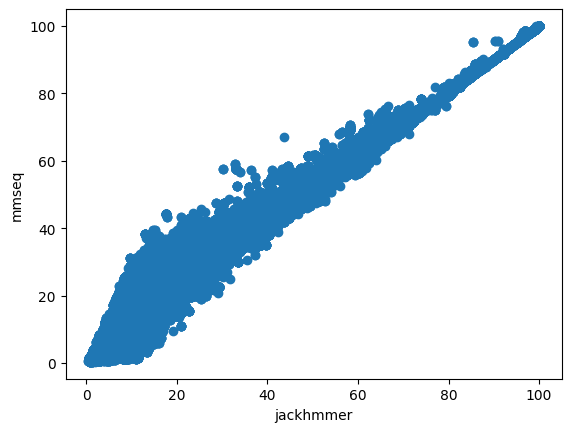

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df["true_identity_percent"], df["identity_percent"])
plt.xlabel("jackhmmer")
plt.ylabel("mmseq")

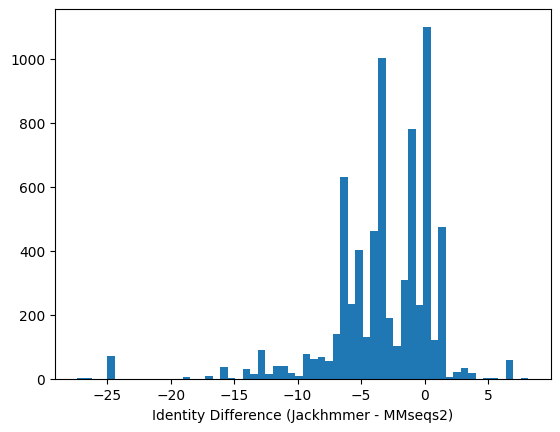

In [15]:
plt.hist(t["true_identity_percent"] - t["identity_percent"], bins=60)
plt.xlabel("Identity Difference (Jackhmmer - MMseqs2)")
plt.show()

#in general mmseq bigger cause betetr alignmnent?

In [14]:
(df["true_identity_percent"] - df["identity_percent"]).max()

10.02

In [ ]:
mmseq_results = pl.read_parquet( "/cluster/project/beltrao/kdammer/master_thesis/scripts/mmseq_homology_match/mmseqs/mmseqs_run_e_value_100/results/mmseqs_identity_similarity_e_value_100.parquet")

In [9]:
mmseq_results.head(5)

protein_id,hit_pdb_id,identity_percent,similarity_percent,evalue,alnlen,qlen,tlen,is_high_homology
str,str,f64,f64,f64,i32,i32,i32,bool
"""p14120""","""6sv4_zY""",100.0,100.0,3.2940e-61,105,105,105,true
"""p14120""","""6xiq_c""",100.0,100.0,3.2940e-61,105,105,105,true
"""p14120""","""6yly_c""",100.0,100.0,3.2940e-61,105,105,105,true
"""p14120""","""6z6k_Lc""",100.0,100.0,3.2940e-61,105,105,105,true
"""p14120""","""7rr5_Lc""",100.0,100.0,3.2940e-61,105,105,105,true


In [10]:
unmapped_complexes.head(5)

#Complex ac,Identifiers (and stoichiometry) of molecules in complex,Cleaned Identifiers,n_proteins
str,str,str,u32
"""CPX-21""","""P22336(1)|P26754(1)|P26755(1)""","""P22336 P26754 P26755""",3
"""CPX-24""","""P38203(1)|P40070(1)|P40089(1)|…","""P38203 P40070 P40089 P47093 P4…",9
"""CPX-44""","""P38203(1)|P40070(1)|P40089(1)|…","""P38203 P40070 P40089 P47093 P5…",7
"""CPX-45""","""P38203(1)|P40070(1)|P40089(1)|…","""P38203 P40070 P40089 P47017 P5…",7
"""CPX-112""","""P25644(1)|P38203(1)|P40070(1)|…","""P25644 P38203 P40070 P40089 P4…",8


In [16]:
P02293_mmseq = mmseq_results.filter(pl.col("protein_id") == "p02293")

## Find best partial /superset complexes

In [2]:
'''
I want to classify the best_match_per_complex_df (from running 4_match_complexes_to_pdb.py) whetehr i deem the match sufficient enough. 
there are two categories I am intrested in. Partial and superset, everzthing else should be no_sufficient_match

Partial: All pdb proteins are in the CP complex, pdb_complex captures at least 50.01 % of the proteins in the CP complex.  ->CP complex bigger
Superset: All CP complex proteins are in the pdb complex, pdb_complex consists of at least 50.01 % of the proteins in the pdb complex.  -> pdb complex bigger

partial: extra-prot = 0 (equivalemt to n_distinct_proteins_pdb - n_matched) , coverage_frac > 0.50 (equivalent to n-matched/n-prot > 0.50)
superset: n-matched = n-prot , coverage_frac > 0.50( n-matched/n-prot > 0.5001)
)
'''

best_match_per_complex = pl.read_csv(data_dir/'complete_complex_pdb_mapping_v2/homology_pdb_mapping/best_match_per_complex.csv')

best_match_per_complex_with_columns = best_match_per_complex.with_columns(
    match_class = pl.when(
        (pl.col("extra_proteins") == 0) & (pl.col("coverage_frac") > 0.50)
    ).then(pl.lit("partial"))
    .when(
        (pl.col("n_matched") == pl.col("n_proteins")) & (pl.col("coverage_frac") > 0.50)
    ).then(pl.lit("superset"))
    .otherwise(pl.lit("no_sufficient_match"))
)
#bibest_match_per_complex_with_columnste_csv(data_dir/'complete_complex_pdb_mapping_v2/homology_pdb_mapping/best_match_per_complex_with_match_class.csv')

create df for all CP complexes that tells me whethre a pdb complex exitsts

In [3]:
best_match_per_complex_with_columns =best_match_per_complex_with_columns.select(['complex_ac', 'n_proteins','pdb_id','match_class'])

In [4]:
exact_homology_matches = pl.read_csv(data_dir/'complete_complex_pdb_mapping_v2/homology_pdb_mapping/exact_matches.csv')
#keep first match for each cp complex

exact_homology_matches = (
    exact_homology_matches
    .group_by("complex_ac", maintain_order=True)
    .first()
    .with_columns(
        match_class=pl.lit("exact_homology_match")
    )
)

exact_homology_matches = exact_homology_matches.select(['complex_ac', 'n_proteins','pdb_id','match_class'])


In [5]:
# complex fow which homology serach didnt find any match (not even one prot?)
no_homology_match = pl.read_csv(data_dir/'complete_complex_pdb_mapping_v2/homology_pdb_mapping/summary_per_complex.csv').filter(~pl.col('best_match_pdb').is_not_null())

no_homology_match = no_homology_match.with_columns(
    match_class=pl.lit("no_homology_match"),
    pdb_id=pl.lit("none")
)

no_homology_match = no_homology_match.select(['complex_ac', 'n_proteins','pdb_id','match_class'])

In [6]:
# complexes for which i have found a match (arreadz without homogz search)

# get amount of proteins for eahc complex/how many proteins are in each complex
Complex_portal_df = pl.read_csv(data_dir/'Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv', separator="\t")
Complex_portal_df = clean_identifiers(Complex_portal_df.select(["#Complex ac", "Identifiers (and stoichiometry) of molecules in complex"]))
Complex_portal_df = count_elements(Complex_portal_df, column="Cleaned Identifiers", separator=" ", new_column_name="n_proteins")
Complex_portal_df = Complex_portal_df.select(['#Complex ac', 'n_proteins'])

exact_pdb_match = pl.read_csv(data_dir/'complete_complex_pdb_mapping_v2/exact_pdb_match/best_coverage_complex/best_coverage_download_log.csv')

In [7]:
# add information on complex size
exact_pdb_match = (
    exact_pdb_match
    .join(
        Complex_portal_df.select([
            pl.col("#Complex ac"),
            pl.col("n_proteins")
        ]),
        left_on="Complex_ac",
        right_on="#Complex ac",
        how="left"
    )
    .with_columns(
        match_class=pl.lit("exact_pdb_match")
    )
)


In [8]:
exact_pdb_match = exact_pdb_match.select(['Complex_ac', 'n_proteins','pdb_id','match_class'])
exact_pdb_match = exact_pdb_match.rename({"Complex_ac": "complex_ac"}).select(['complex_ac', 'n_proteins','pdb_id','match_class'])


In [10]:
#concatenate all df 
pdb_match_dataframes = [
    exact_pdb_match,
    exact_homology_matches, 
    no_homology_match,
    best_match_per_complex_with_columns,
]

pdb_match_dataframes = [
    pdb_matches.with_columns(
        pl.col("n_proteins").cast(pl.Int64)
    )
    for pdb_matches in pdb_match_dataframes
]

all_pdb_matches = pl.concat(pdb_match_dataframes)

In [13]:
def keep_only_exact_match_if_present(df: pl.DataFrame) -> pl.DataFrame:
    exact_complexes = (
        df.filter(pl.col("match_class") == "exact_pdb_match")
        .get_column("complex_ac")
        .unique()
        .to_list()
    )

    return df.filter(
        ~pl.col("complex_ac").is_in(exact_complexes)
        | (pl.col("match_class") == "exact_pdb_match")
    )

all_pdb_matches = keep_only_exact_match_if_present(all_pdb_matches)

In [ ]:
# remove matches if complex already has an exact match (exact_pdb_match) or an exact homology match (exact_homology_matches)

In [ ]:
#all_pdb_matches.write_csv(data_dir/'complete_complex_pdb_mapping_v2/all_pdb_matches_with_match_class.csv')

In [14]:
# count entries for each match class
all_pdb_matches_summary = all_pdb_matches.group_by(pl.col('match_class')).agg(
    pl.len().alias('n_complexes')
).sort('match_class')

all_pdb_matches_summary

match_class,n_complexes
str,u32
"""exact_homology_match""",45
"""exact_pdb_match""",152
"""no_homology_match""",70
"""no_sufficient_match""",263
"""partial""",38
"""superset""",66


In [15]:
# how for cplexes bigger 2, should be 374 in total 
bigger_complexes_pdb_matches_summary = all_pdb_matches.filter(pl.col('n_proteins') > 2).group_by(pl.col('match_class')).agg(
    pl.len().alias('n_complexes')
).sort('match_class')

bigger_complexes_pdb_matches_summary

match_class,n_complexes
str,u32
"""exact_homology_match""",13
"""exact_pdb_match""",71
"""no_homology_match""",24
"""no_sufficient_match""",183
"""partial""",38
"""superset""",45


## Check homolgy pdb matching with new pdb file compared to old one

In [24]:
exact_match_MMseq = all_pdb_matches.join(
    exact_pdb_match
        .select(["complex_ac", "pdb_id"])
        .rename({"pdb_id": "pdb_id_CP"}),
    on="complex_ac",
    how="right",
)

Do I get more hits for all proteins with the new pdb file

no, not necesarily, but i mostlz loose low quality hits (only 9,952 of the 1,689,677 have a idetntiz score of more than 30), the verz high confidence ones have been replaced by other structures

In [17]:
old_mmseq_results = pl.read_parquet( "/cluster/project/beltrao/kdammer/master_thesis/scripts/mmseq_homology_match/mmseqs/old_pdb_mmseqs_run_e_value_100/results/mmseqs_identity_similarity_e_value_100.parquet")
mmseq_results = pl.read_parquet( "/cluster/project/beltrao/kdammer/master_thesis/scripts/mmseq_homology_match/mmseqs/mmseqs_run_max_sensitivity/results/mmseqs_identity_similarity_max_sensitivity.parquet")

In [57]:
mmseq_results_P02309 = mmseq_results.filter(pl.col("protein_id") == "P02309")

In [35]:
mmseq_results.head(2)

protein_id,hit_pdb_id,identity_percent,similarity_percent,evalue,alnlen,qlen,tlen,is_high_homology
str,str,f64,f64,f64,i32,i32,i32,bool
"""P25045""","""8c82_B""",100.0,100.0,0.0,558,558,558,true
"""P25045""","""8c82_F""",100.0,100.0,0.0,558,558,558,true


In [38]:
old_mmseq_results = old_mmseq_results.with_columns(
    pl.col("protein_id").str.to_uppercase()
)

old_mmseq_results_res_count = (
    old_mmseq_results
    .group_by("protein_id")
    .len()
    .rename({"len": "n_hits_old_mmseqs"})
)


mmseq_results_res_count = (
    mmseq_results
    .group_by("protein_id")
    .len()
    .rename({"len": "n_hits_mmseqs"})
)

mmseq_results_res_count = mmseq_results_res_count.join(
    old_mmseq_results_res_count,
    on="protein_id",
    how="left",
)

In [ ]:
mmseq_results_res_count = mmseq_results_res_count.with_columns(
    more_hits = pl.when(pl.col("n_hits_mmseqs") > pl.col("n_hits_old_mmseqs")).then(pl.lit(True)).otherwise(pl.lit(False))
)

old_mmseq_results_Q12431 = old_mmseq_results.filter(pl.col("protein_id") == "Q12431")
mmseq_results_Q12431 = mmseq_results.filter(pl.col("protein_id") == "Q12431")

In [ ]:
prot_in_both = mmseq_results_res_count

In [55]:
# Perform an anti-join on protein_id and hit_pdb_id
# 1. Get the unique protein_ids from the new results
new_proteins = mmseq_results.select("protein_id").unique()

# 2. Filter old results to these proteins, then find the missing hits
only_in_old = (
    old_mmseq_results
    .join(new_proteins, on="protein_id", how="semi")
    .join(mmseq_results, on=["protein_id", "hit_pdb_id"], how="anti")
)

In [44]:
# check for 763	Q12431	48	264.0	False
old_mmseq_results_Q12431 = old_mmseq_results.filter(pl.col("protein_id") == "Q12431")
mmseq_results_Q12431 = mmseq_results.filter(pl.col("protein_id") == "Q12431")

Do i get high idnetitz scores for matches that are made on protein id (as sometimes the sequence on pdb compared to pdb can differ (pdb is shorter) -> low identitz score) e.g  P53741	1zx2_B	from (CPX-1412, ha sno homolghz, but excat match)

In [60]:
import polars as pl

def check_protein_chain_mapping(
    downloaded_exact_matches: pl.DataFrame,
    complex_protein_map: pl.DataFrame,
    mmseq_res: pl.DataFrame | pl.LazyFrame,
) -> pl.DataFrame:
    """
    For each protein in each downloaded exact-match complex, find the
    BEST-matching PDB chain (highest identity_percent) in mmseq_res,
    along with its identity/similarity/coverage stats.
    """
    complex_proteins = (
        complex_protein_map
        .select(
            pl.col("#Complex ac").alias("Complex_ac"),
            pl.col("Cleaned Identifiers").str.split(" ").alias("protein_id"),
        )
        .explode("protein_id")
    )

    target_pairs = (
        downloaded_exact_matches
        .select("Complex_ac", "pdb_id")
        .join(complex_proteins, on="Complex_ac", how="left")
        .with_columns(pl.col("pdb_id").str.to_uppercase())
    )

    relevant_proteins = target_pairs["protein_id"].unique().to_list()
    relevant_pdb_ids = target_pairs["pdb_id"].unique().to_list()

    mmseq_lazy = mmseq_res.lazy() if isinstance(mmseq_res, pl.DataFrame) else mmseq_res

    mmseq_filtered = (
        mmseq_lazy
        .filter(pl.col("protein_id").is_in(relevant_proteins))
        .with_columns(
            pl.col("hit_pdb_id").str.split("_").list.first().str.to_uppercase().alias("pdb_id"),
            pl.col("hit_pdb_id").str.split("_").list.last().alias("chain"),
        )
        .filter(pl.col("pdb_id").is_in(relevant_pdb_ids))
        .select(
            "protein_id", "pdb_id", "chain",
            "identity_percent", "similarity_percent",
            "alnlen", "qlen", "tlen", "evalue",
        )
        .collect()
    )

    # Keep only the best-identity chain per (protein_id, pdb_id)
    best_per_pdb = (
        mmseq_filtered
        .sort("identity_percent", descending=True)
        .group_by(["protein_id", "pdb_id"], maintain_order=True)
        .first()
    )

    result = target_pairs.join(best_per_pdb, on=["protein_id", "pdb_id"], how="left")

    return result.sort(["Complex_ac", "protein_id"])

In [48]:
downloaded_exact_matches = pl.read_csv(data_dir/ "complete_complex_pdb_mapping_v2/exact_pdb_match/best_coverage_complex/best_coverage_download_log.csv")
complex_protein_map = pl.read_csv(data_dir/ "Complex_Portal/Sc_ComplexTab_cleaned.csv")

In [62]:
exact_homology_match = check_protein_chain_mapping(downloaded_exact_matches, complex_protein_map, mmseq_res)


# proteins with no hit at all in their assigned PDB (suspicious "exact matches")
#no_hit = exact_homology_match.filter(pl.col("chain").is_null())

# proteins matched but with low identity despite being an "exact" complex match
#low_identity = result.filter(pl.col("identity_percent") < 90)

In [ ]:
excat_homology_match= check_exact_match_homology(downloaded_exact_matches, mmseq_results)
print(excat_homology_match)

shape: (152, 14)
┌────────────┬────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ Complex_ac ┆ pdb_id ┆ assembly   ┆ Overall_c ┆ … ┆ max_ident ┆ min_simil ┆ mean_simi ┆ max_simil │
│ ---        ┆ ---    ┆ ---        ┆ overage   ┆   ┆ ity_perce ┆ arity_per ┆ larity_pe ┆ arity_per │
│ str        ┆ str    ┆ str        ┆ ---       ┆   ┆ nt        ┆ cent      ┆ rcent     ┆ cent      │
│            ┆        ┆            ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│            ┆        ┆            ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ CPX-1556   ┆ 7AJU   ┆ biological ┆ null      ┆ … ┆ 100.0     ┆ 1.78      ┆ 19.977809 ┆ 100.0     │
│            ┆        ┆ _assembly_ ┆           ┆   ┆           ┆           ┆           ┆           │
│            ┆        ┆ 1_closest_ ┆           ┆   ┆           ┆          

In [ ]:
# Rows where the pdb_id has no hits in mmseq_res at all, or low identity despite being "exact"
suspicious = result.filter(
    (pl.col("n_hits_for_pdb").is_null()) | (pl.col("max_identity_percent") < 90)
)
print(suspicious)

## how many Complexs where structure is unknown have intresting stoichiometry


In [17]:
all_pdb_matches = pl.read_csv(data_dir/'complete_complex_pdb_mapping_v2/all_pdb_matches_with_match_class.csv')

In [18]:
Complex_Tab = pl.read_csv(data_dir / "Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv", separator="\t")
Complex_Tab = add_interesting_stoichiometry(Complex_Tab, column= "Identifiers (and stoichiometry) of molecules in complex",check_stoichiometry_given=True)

In [19]:
all_pdb_matches = all_pdb_matches.join(
    Complex_Tab.select(
        [
            pl.col("#Complex ac"),
            pl.col("Identifiers (and stoichiometry) of molecules in complex"),
            pl.col("interesting_stoichiometry"),
            pl.col("stoichiometry_given"),
        ]
    ),
    left_on="complex_ac",
    right_on="#Complex ac",
    how="left",
)

In [12]:
all_pdb_matches.select(pl.col("match_class").unique())

match_class
str
"""no_homology_match"""
"""no_sufficient_match"""
"""partial"""
"""superset"""
"""exact_homology_match"""
"""exact_pdb_match"""


In [20]:
all_pdb_matches_big_interesting_stoi = all_pdb_matches.filter(
    (pl.col("n_proteins") > 2)
    & (pl.col("match_class").is_in(["no_homology_match", "no_sufficient_match"]))
)

In [ ]:
#P06777(1)|P06838(1)|Q12098(1)

In [23]:
mmseq_results = pl.read_parquet("/cluster/project/beltrao/kdammer/master_thesis/scripts/mmseq_homology_match/mmseqs/mmseqs_run_max_sensitivity/results/mmseqs_identity_similarity_max_sensitivity.parquet")

In [24]:
mmseq_P06777 = mmseq_results.filter(pl.col("protein_id") == "P06777")

## What complexes have no homology

In [3]:
all_pdb_match_classes = pl.read_csv(data_dir/ 'complete_complex_pdb_mapping_v2/all_pdb_matches_with_match_class.csv')

In [5]:
big_complexes_pdb_match_classes_no_homology = all_pdb_match_classes.filter((pl.col("n_proteins")>2 )& (pl.col('match_class')=="no_homology_match"))

In [7]:
big_complexes_pdb_match_classes_no_homology.write_csv(PRJ_ROOT/ "tmp/big_complexes_pdb_match_classes_no_homology.csv")